# Documents as Vectors: From TF-IDF to RAG

## Environment Setup (Miniconda + Jupyter)

### Step 1. Check if Miniconda is installed
Run in terminal:
```
conda --version
```
If not installed, download and install from:
https://docs.conda.io/en/latest/miniconda.html

### Step 2. Create a virtual environment
```
conda create --name jupyterconda python=3.11 jupyter -y
```

## Step 3: Activate Environment
```
conda activate jupyterconda
```

### 4. Install Jupyter
```
conda install jupyter -y
```

### 5. Install dependencies
```
pip install numpy pandas scikit-learn matplotlib
conda install seaborn openpyxl -y
```

### 6. Test Jupyter
```
jupyter notebook .\notebook.ipynb
```

If it opens in your browser, you're ready.


## A Story: The Librarian and the AI Assistant

Imagine a small college library in Ontario.

A student walks in and asks:
> *"Can you help me understand how climate change affects agriculture?"*

The librarian doesn't read every book from scratch. Instead:
- She remembers which books talk about *climate*, *agriculture*, and *impact*
- She quickly identifies the most relevant ones
- Then she opens those and extracts the answer

Now imagine replacing the librarian with a **RAG (Retrieval-Augmented Generation)** system.

The system:
1. Searches documents
2. Finds the most relevant ones
3. Feeds them to a language model
4. Generates an answer

But here's the key question:

👉 **How does the system know which documents are relevant?**


## The Bridge: From TF-IDF to Documents as Vectors

Last week, we learned:

- TF-IDF assigns importance to words
- Words that are common everywhere → low value
- Words that are unique to a document → high value

Now we take the next step:

👉 Instead of just scoring words, we represent entire documents as vectors.

### Key Idea:
- Each word in the vocabulary = a dimension
- Each document = a vector of TF-IDF scores

So if we have a vocabulary of size |V|:

➡️ Each document becomes a **|V|-dimensional vector**

This is the **Vector Space Model**.


## Vector Space Model

- Terms = axes (dimensions)
- Documents = points in space
- Each coordinate = TF-IDF weight

Example:

Vocabulary = [climate, agriculture, economy]

Document A → [0.8, 0.6, 0.0]  
Document B → [0.1, 0.0, 0.9]

These vectors are:
- High dimensional
- Very sparse


## How TF-IDF Fits into RAG

Let’s connect everything.

### RAG Pipeline (Simplified)

1. User asks a question
2. Convert query into a vector (using TF-IDF or embeddings)
3. Compare with document vectors
4. Retrieve most similar documents
5. Send to LLM → generate answer

### Where TF-IDF Helps

TF-IDF is used to:
- Represent documents as vectors
- Represent the query as a vector
- Compute similarity (e.g., cosine similarity)

👉 Documents with similar important terms will be closer in vector space.

This is exactly how the "librarian" finds relevant books.


## Example: TF-IDF + Similarity

In [1]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

documents = [
    "climate change affects agriculture",
    "stock market and economy trends",
    "farming and agriculture techniques"
]

query = ["impact of climate on farming"]


# Initialize the TF-IDF vectorizer
# This object will:
# - Build a vocabulary from the input documents
# - Compute term frequency (TF)
# - Compute inverse document frequency (IDF)
# - Combine them into TF-IDF scores
vectorizer = TfidfVectorizer()

# Learn the vocabulary from the documents AND transform them into TF-IDF vectors
# - fit(): scans all documents to learn vocabulary and IDF values
# - transform(): converts each document into a vector of TF-IDF scores
# Result: a sparse matrix of shape (num_documents, vocab_size)
doc_vectors = vectorizer.fit_transform(documents)

# Transform the query into the SAME vector space
# Important:
# - We do NOT call fit_transform here
# - This ensures the query uses the same vocabulary and IDF weights as the documents
# Result: a vector of shape (1, vocab_size)
query_vector = vectorizer.transform(query)

# Compute cosine similarity between the query and each document
# Cosine similarity measures the angle between vectors:
# - 1 → very similar (same direction)
# - 0 → not similar (orthogonal)
# Output shape: (1, num_documents)
similarities = cosine_similarity(query_vector, doc_vectors)

# Print similarity scores for each document
# Each value corresponds to how relevant a document is to the query
print("Similarity scores:", similarities)

# Find the index of the most similar document
# argmax() returns the position of the highest similarity score
most_relevant_index = similarities.argmax()

# Retrieve and print the most relevant document
print("Most relevant document:", documents[most_relevant_index])

Similarity scores: [[0.37380112 0.         0.39798027]]
Most relevant document: farming and agriculture techniques


## Key Takeaways

- TF-IDF gives importance to terms
- Documents become vectors in a high-dimensional space
- Similarity between documents = distance in that space
- RAG uses this idea to retrieve relevant context

👉 TF-IDF is one of the earliest ways to power retrieval systems
👉 Modern systems use embeddings, but the idea is the same


## Visualizing Document Vectors

TF-IDF vectors are high-dimensional, which makes them hard to visualize directly.

To visualize them, we:
1. Reduce dimensions (e.g., using PCA)
2. Plot in 2D

This helps us *see* how documents and queries relate in vector space.


Number of documents: 3
TF-IDF vector dimension (|V|): 11
Each document is a point in R^11


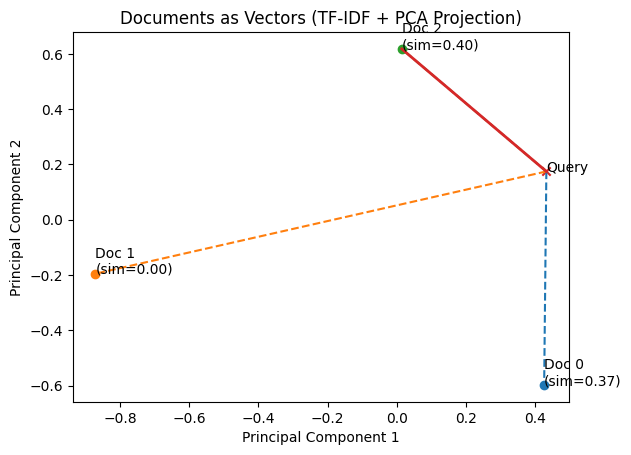


Query: impact of climate on farming
Most similar document: farming and agriculture techniques
Similarity score: 0.3980


In [2]:
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import numpy as np

# --- Step 1: Inspect vector space dimensionality ---
vocab_size = doc_vectors.shape[1]
num_docs = doc_vectors.shape[0]

print(f"Number of documents: {num_docs}")
print(f"TF-IDF vector dimension (|V|): {vocab_size}")
print(f"Each document is a point in R^{vocab_size}")

# --- Step 2: Convert sparse → dense for visualization ---
doc_dense = doc_vectors.toarray()
query_dense = query_vector.toarray()

# --- Step 3: Combine for joint PCA projection ---
combined = np.vstack([doc_dense, query_dense])

# --- Step 4: Reduce to 2D (for visualization only) ---
pca = PCA(n_components=2)
reduced = pca.fit_transform(combined)

doc_points = reduced[:num_docs]
query_point = reduced[-1]

# --- Step 5: Compute cosine similarity (true similarity in high-dim space) ---
similarities = cosine_similarity(query_vector, doc_vectors)[0]
nearest_idx = np.argmax(similarities)

# --- Step 6: Plot ---
plt.figure()

# Plot documents
for i, point in enumerate(doc_points):
    plt.scatter(point[0], point[1])
    plt.text(point[0], point[1], f"Doc {i}\n(sim={similarities[i]:.2f})")

# Plot query (distinct marker)
plt.scatter(query_point[0], query_point[1], marker='x')
plt.text(query_point[0], query_point[1], "Query")

# --- Step 7: Draw lines to show "distance = similarity" ---
for i, point in enumerate(doc_points):
    plt.plot(
        [query_point[0], point[0]],
        [query_point[1], point[1]],
        linestyle='dashed'
    )

# Highlight nearest neighbor
nearest_point = doc_points[nearest_idx]
plt.plot(
    [query_point[0], nearest_point[0]],
    [query_point[1], nearest_point[1]],
    linewidth=2
)

plt.title("Documents as Vectors (TF-IDF + PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

# --- Step 8: Explicit retrieval result ---
print("\nQuery:", query[0])
print("Most similar document:", documents[nearest_idx])
print(f"Similarity score: {similarities[nearest_idx]:.4f}")